# Notebook 06 — AutoReg

Este notebook implementa el modelo AutoReg para la predicción de la
huella de carbono operacional del sistema eléctrico español con
resolución horaria (1h).

AutoReg es una regresión lineal directa sobre un gran número de rezagos,
lo que lo hace computacionalmente eficiente y capaz de capturar
dependencias de largo alcance sin el coste del espacio de estados.
Con resolución horaria los lags equivalentes son 4 veces menores
que a 15 minutos (lags=144 equivale a 6 días frente a lags=576).

**Features:** solo rezagos de la serie (sin variables exógenas)

**Evaluación:** walk-forward con 45 evaluaciones distribuidas por 2024,
paso de 8 días (no múltiplo de 7 para evitar sesgo por día de la semana),
ventana expansiva.

**Horizontes:** 48h (48 pasos) y 72h (72 pasos).

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.dates as mdates
from pathlib import Path
from dataclasses import dataclass
from sklearn.metrics import mean_absolute_error, mean_squared_error
from statsmodels.tsa.ar_model import AutoReg
import warnings
warnings.filterwarnings("ignore")

plt.style.use("seaborn-v0_8")
%matplotlib inline

BASE_DIR    = Path("/srv/TFM") if Path("/srv/TFM").exists() else Path("/home/ubuntu/TFM")
DATA_DIR    = BASE_DIR / "notebooks/data_processed"
RESULTS_DIR = BASE_DIR / "results"
FIG_DIR     = BASE_DIR / "figures"
RESULTS_DIR.mkdir(exist_ok=True)
FIG_DIR.mkdir(exist_ok=True)

print("BASE_DIR:", BASE_DIR)
print("Existe:", BASE_DIR.exists())

BASE_DIR: /home/ubuntu/TFM
Existe: True


## 1. Carga de datos

Se cargan los parquets generados en el notebook 01 a resolución horaria (1h).
La división temporal es idéntica al resto de modelos:
- Train: 2022–2023 (~17.520 observaciones)
- Validación: 2024 (~8.784 observaciones)
- Test: 2025

In [2]:
y_train = pd.read_parquet(DATA_DIR / "train_2022_2023.parquet")["y"].astype(float)
y_val   = pd.read_parquet(DATA_DIR / "val_2024.parquet")["y"].astype(float)
y_test  = pd.read_parquet(DATA_DIR / "test_2025.parquet")["y"].astype(float)

y_train.index = pd.to_datetime(y_train.index)
y_val.index   = pd.to_datetime(y_val.index)
y_test.index  = pd.to_datetime(y_test.index)

print("Train:", y_train.shape, "|", y_train.index.min(), "->", y_train.index.max())
print("Val:  ", y_val.shape,   "|", y_val.index.min(),   "->", y_val.index.max())
print("Test: ", y_test.shape,  "|", y_test.index.min(),  "->", y_test.index.max())

Train: (17520,) | 2022-01-01 00:00:00+00:00 -> 2023-12-31 23:00:00+00:00
Val:   (8784,) | 2024-01-01 00:00:00+00:00 -> 2024-12-31 23:00:00+00:00
Test:  (8760,) | 2025-01-01 00:00:00+00:00 -> 2025-12-31 23:00:00+00:00


## 2. Configuración temporal y métricas

Con resolución horaria (1h):
- 1 hora = 1 paso
- 24 horas = 24 pasos (periodo estacional diario)
- 48 horas = 48 pasos
- 72 horas = 72 pasos

Se definen las métricas (MAE, RMSE) y las funciones de bootstrap
para calcular intervalos de confianza al 95% sobre las 45 evaluaciones.

In [3]:
FREQ_MIN        = 60
STEPS_PER_HOUR  = 1
SEASONAL_PERIOD = 24

HORIZONS = {
    "48h": 48,
    "72h": 72,
}

@dataclass
class WFConfig:
    step: int
    min_history: int
    max_fits: int

def compute_metrics(y_true, y_pred):
    mae  = mean_absolute_error(y_true, y_pred)
    rmse = np.sqrt(mean_squared_error(y_true, y_pred))
    return {"MAE": mae, "RMSE": rmse}

def bootstrap_ci(errors, n_boot=1000, ci=95):
    rng = np.random.default_rng(42)
    boot_means = np.array([
        rng.choice(errors, size=len(errors), replace=True).mean()
        for _ in range(n_boot)
    ])
    lower = np.percentile(boot_means, (100 - ci) / 2)
    upper = np.percentile(boot_means, 100 - (100 - ci) / 2)
    return lower, upper

def summarize_with_ci(df, model_name):
    rows = []
    for horizon, group in df.groupby("horizon"):
        mae_vals  = group["MAE"].values
        rmse_vals = group["RMSE"].values
        mae_lo,  mae_hi  = bootstrap_ci(mae_vals)
        rmse_lo, rmse_hi = bootstrap_ci(rmse_vals)
        rows.append({
            "model":      model_name,
            "horizon":    horizon,
            "MAE_mean":   mae_vals.mean(),
            "MAE_std":    mae_vals.std(),
            "MAE_ci_lo":  mae_lo,
            "MAE_ci_hi":  mae_hi,
            "RMSE_mean":  rmse_vals.mean(),
            "RMSE_std":   rmse_vals.std(),
            "n_eval":     len(mae_vals),
        })
    return pd.DataFrame(rows)

def summarize(df, model_name):
    out = (
        df.groupby("horizon")[["MAE", "RMSE"]]
        .mean()
        .reset_index()
    )
    out.insert(0, "model", model_name)
    return out

cfg = WFConfig(
    step=8 * SEASONAL_PERIOD,
    min_history=7 * SEASONAL_PERIOD,
    max_fits=45
)

PLOT_INDICES = [2, 15, 30, 42]

print("Periodo estacional:", SEASONAL_PERIOD)
print("Horizontes:", HORIZONS)
print(f"cfg: step={cfg.step} pasos (8 días) | min_history={cfg.min_history} | max_fits={cfg.max_fits}")

Periodo estacional: 24
Horizontes: {'48h': 48, '72h': 72}
cfg: step=192 pasos (8 días) | min_history=168 | max_fits=45


## 3. Función de predicción AutoReg

AutoReg ajusta una regresión lineal OLS donde los predictores son
los últimos `lags` valores observados de la serie. Con resolución
horaria los valores de lags equivalentes son:
- lags=24  → 1 día de memoria
- lags=96  → 4 días de memoria
- lags=192 → 8 días de memoria
- lags=336 → 14 días de memoria (óptimo)
- lags=576 → 24 días de memoria

In [4]:
def forecast_autoreg(train, h, lags=576):
    model     = AutoReg(train.values, lags=lags, trend="n")
    model_fit = model.fit()
    n         = len(train)
    preds     = model_fit.predict(
        start=n,
        end=n + h - 1,
        dynamic=False
    )
    return preds
print("forecast_autoreg definida OK")

forecast_autoreg definida OK


## 4. Estrategia de evaluación — Walk-forward

Se utiliza una estrategia de validación walk-forward con ventana expansiva
para evaluar el modelo en condiciones realistas de producción. En cada
punto de evaluación, el modelo se reentrena con todo el histórico
disponible hasta ese momento (datos de entrenamiento 2022-2023 más los
datos de validación acumulados) y genera predicciones a 48h y 72h.

Se realizan 45 evaluaciones distribuidas a lo largo de 2024 con un paso
de 8 días (no múltiplo de 7 para evitar sesgo por día de la semana).
El primer punto de evaluación cae el 8 de enero de 2024 y el último
el 24 de diciembre de 2024, cubriendo prácticamente todo el año de
validación.

Para cada evaluación se calcula el MAE y el RMSE de la predicción.
Los resultados finales se reportan como media ± desviación estándar
sobre las 45 evaluaciones, junto con un intervalo de confianza al 95%
estimado mediante bootstrap con 1000 iteraciones sobre los errores
individuales.

Esta estrategia permite cuantificar no solo el error medio del modelo
sino también su variabilidad temporal a lo largo del año de validación,
lo que proporciona una evaluación más robusta y representativa del
rendimiento real esperado en producción.

In [5]:
def walk_forward_splits(series, horizons, cfg):
    n      = len(series)
    max_h  = max(horizons.values())
    points = list(range(cfg.min_history, n - max_h, cfg.step))
    points = points[:cfg.max_fits]
    for t0 in points:
        train_part = series.iloc[:t0]
        tests = {k: series.iloc[t0:t0 + h] for k, h in horizons.items()}
        yield train_part, tests

def evaluate_autoreg(y_train, y_val, horizons, cfg, lags=576, verbose=True):
    rows        = []
    preds_store = []
    y_full  = pd.concat([y_train, y_val]).sort_index()
    n_train = len(y_train)
    splits  = list(walk_forward_splits(y_val, horizons, cfg))
    total   = len(splits)
    for i, (train_part, tests) in enumerate(splits, 1):
        if verbose:
            print(f"Fit {i}/{total}")
        cutoff_idx   = n_train + len(train_part)
        cutoff_time  = y_full.index[cutoff_idx - 1]
        train_window = y_full.iloc[:cutoff_idx]
        fit_preds = {"cutoff_time": cutoff_time, "train_window": train_window}
        for name, test in tests.items():
            pred = forecast_autoreg(train_window, len(test), lags)
            m    = compute_metrics(test.values, pred)
            rows.append({"horizon": name, "MAE": m["MAE"], "RMSE": m["RMSE"]})
            fit_preds[name] = {"pred": pred, "test": test}
        preds_store.append(fit_preds)
    return pd.DataFrame(rows), preds_store
print("Walk-forward definido OK")

Walk-forward definido OK


In [6]:
resultados_lags = []

for lags in [24, 48, 96, 144, 192, 240, 288, 336, 384, 432, 480, 528, 576]:
    print(f"\nProbando lags={lags}...")
    df_res, _ = evaluate_autoreg(
        y_train, y_val,
        HORIZONS, cfg,
        lags=lags,
        verbose=False
    )
    summary = summarize(df_res, f"AutoReg({lags})")
    resultados_lags.append(summary)
    print(summary)

comparacion_lags = pd.concat(resultados_lags, ignore_index=True)
print("\n--- COMPARACIÓN FINAL ---")
print(comparacion_lags)
comparacion_lags.to_csv(RESULTS_DIR / "autoreg_lags_search.csv", index=False)


Probando lags=24...
         model horizon        MAE       RMSE
0  AutoReg(24)     48h  19.741021  24.349907
1  AutoReg(24)     72h  22.731786  27.830377

Probando lags=48...
         model horizon        MAE       RMSE
0  AutoReg(48)     48h  18.855327  23.196334
1  AutoReg(48)     72h  21.451834  26.180563

Probando lags=96...
         model horizon        MAE       RMSE
0  AutoReg(96)     48h  18.353802  22.555147
1  AutoReg(96)     72h  20.538122  25.080556

Probando lags=144...
          model horizon        MAE       RMSE
0  AutoReg(144)     48h  18.321659  22.423628
1  AutoReg(144)     72h  20.363133  24.694162

Probando lags=192...
          model horizon        MAE       RMSE
0  AutoReg(192)     48h  18.116450  22.183631
1  AutoReg(192)     72h  20.108756  24.384244

Probando lags=240...
          model horizon        MAE       RMSE
0  AutoReg(240)     48h  18.049258  22.111631
1  AutoReg(240)     72h  19.893269  24.121942

Probando lags=288...
          model horizon       

## 6. Selección del número de lags óptimo

La búsqueda exhaustiva sobre el conjunto de validación identifica
**lags=336 (14 días de memoria)** como valor óptimo, minimizando
la suma MAE 48h + MAE 72h. La curva de error muestra una mejora
progresiva desde lags=24 hasta lags=336, a partir del cual las
mejoras son marginales y no justifican el coste computacional adicional.

Este resultado es coherente con la naturaleza de la serie — 14 días
de memoria capturan el patrón semanal completo (2 semanas) y la
variabilidad de corto plazo sin introducir ruido de dependencias
demasiado lejanas.

--- Suma MAE 48h + 72h por número de lags ---
           model    MAE_sum
5   AutoReg(336)  36.366198
6   AutoReg(384)  36.414972
7   AutoReg(432)  36.525066
4   AutoReg(288)  36.702020
10  AutoReg(528)  36.802247
11  AutoReg(576)  37.026077
9   AutoReg(480)  37.068267
3   AutoReg(240)  37.942527
1   AutoReg(192)  38.225206
0   AutoReg(144)  38.684792
12   AutoReg(96)  38.891924
8    AutoReg(48)  40.307161
2    AutoReg(24)  42.472807

Lags óptimo seleccionado: 336 (14 días de memoria)


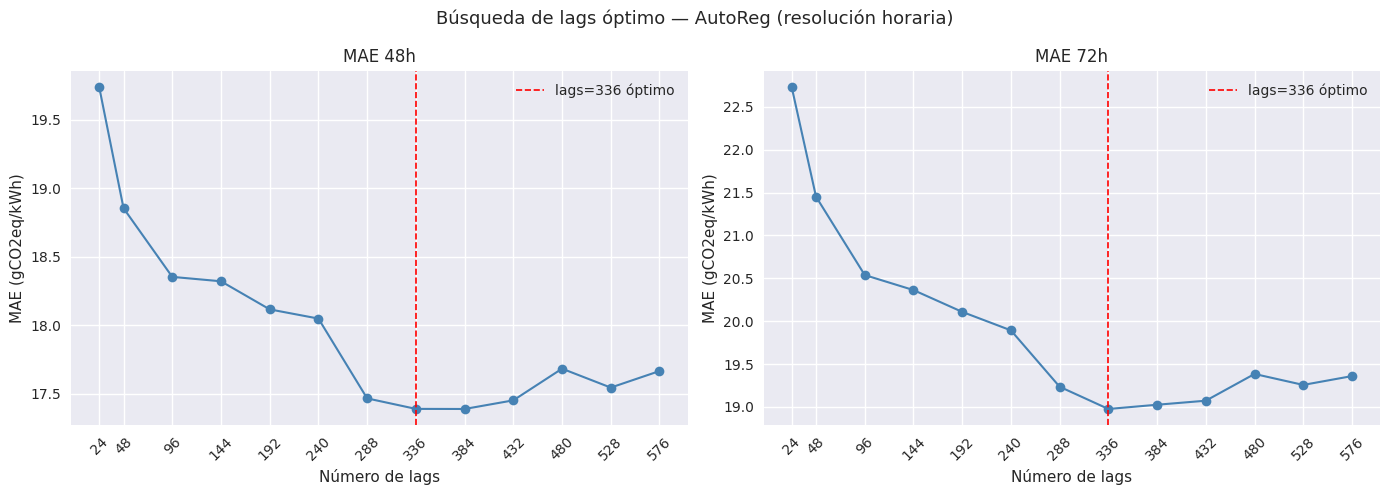

In [7]:
# Selección automática del lags óptimo por suma MAE 48h + 72h
mae_sum = (
    comparacion_lags.groupby("model")["MAE"]
    .sum()
    .reset_index()
    .rename(columns={"MAE": "MAE_sum"})
    .sort_values("MAE_sum")
)
print("--- Suma MAE 48h + 72h por número de lags ---")
print(mae_sum)

best_model = mae_sum.iloc[0]["model"]
LAGS_OPT   = int(best_model.split("(")[1].rstrip(")"))
print(f"\nLags óptimo seleccionado: {LAGS_OPT} ({LAGS_OPT // SEASONAL_PERIOD} días de memoria)")

# Visualización
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
fig.suptitle("Búsqueda de lags óptimo — AutoReg (resolución horaria)", fontsize=13)

lags_vals = [24, 48, 96, 144, 192, 240, 288, 336, 384, 432, 480, 528, 576]

for ax, horizon in zip(axes, ["48h", "72h"]):
    mae_vals = comparacion_lags[
        comparacion_lags["horizon"] == horizon
    ]["MAE"].values
    ax.plot(lags_vals, mae_vals, marker="o",
            color="steelblue", linewidth=1.5)
    ax.axvline(x=LAGS_OPT, color="red", linestyle="--",
               linewidth=1.2, label=f"lags={LAGS_OPT} óptimo")
    ax.set_title(f"MAE {horizon}")
    ax.set_xlabel("Número de lags")
    ax.set_ylabel("MAE (gCO2eq/kWh)")
    ax.set_xticks(lags_vals)
    ax.tick_params(axis="x", rotation=45)
    ax.legend()

plt.tight_layout()
plt.savefig(FIG_DIR / "autoreg_lags_search.png", dpi=150, bbox_inches="tight")
plt.show()

## 7. Modelo final — AutoReg(336)

Se entrena el modelo final con el número de lags óptimo seleccionado
en la fase anterior y se evalúa con el walk-forward completo de 45
evaluaciones distribuidas por 2024. Se reportan MAE y RMSE medios
junto con los intervalos de confianza al 95% por bootstrap.

In [8]:
print(f"Entrenando AutoReg({LAGS_OPT})...")
autoreg_val, preds_store = evaluate_autoreg(
    y_train, y_val,
    HORIZONS, cfg,
    lags=LAGS_OPT,
    verbose=True
)

autoreg_summary = summarize(autoreg_val, f"AutoReg({LAGS_OPT})")
autoreg_ci = summarize_with_ci(autoreg_val, f"AutoReg({LAGS_OPT})")

autoreg_summary.to_csv(RESULTS_DIR / "autoreg_summary.csv", index=False)
autoreg_ci.to_csv(RESULTS_DIR / "autoreg_ci.csv", index=False)

print("\n=== Resultados con IC 95% ===")
for _, r in autoreg_ci.iterrows():
    print(f"{r['model']:20s} {r['horizon']:4s}  "
          f"MAE = {r['MAE_mean']:.2f} ± {r['MAE_std']:.2f}  "
          f"[{r['MAE_ci_lo']:.2f}, {r['MAE_ci_hi']:.2f}]  "
          f"(n={int(r['n_eval'])})")

Entrenando AutoReg(336)...
Fit 1/45


Fit 2/45
Fit 3/45
Fit 4/45
Fit 5/45
Fit 6/45
Fit 7/45
Fit 8/45
Fit 9/45
Fit 10/45
Fit 11/45
Fit 12/45
Fit 13/45
Fit 14/45
Fit 15/45
Fit 16/45
Fit 17/45
Fit 18/45
Fit 19/45
Fit 20/45
Fit 21/45
Fit 22/45
Fit 23/45
Fit 24/45
Fit 25/45
Fit 26/45
Fit 27/45
Fit 28/45
Fit 29/45
Fit 30/45
Fit 31/45
Fit 32/45
Fit 33/45
Fit 34/45
Fit 35/45
Fit 36/45
Fit 37/45
Fit 38/45
Fit 39/45
Fit 40/45
Fit 41/45
Fit 42/45
Fit 43/45
Fit 44/45
Fit 45/45

=== Resultados con IC 95% ===
AutoReg(336)         48h   MAE = 17.39 ± 14.24  [13.58, 22.32]  (n=45)
AutoReg(336)         72h   MAE = 18.98 ± 15.25  [14.77, 24.02]  (n=45)


## 9. Visualización — predicciones vs real (48h)

Se muestran las predicciones a 48h del modelo AutoReg en 4 puntos
distribuidos por 2024 — invierno, primavera, verano y otoño —
para evaluar visualmente la calidad del ajuste en distintas
épocas del año.

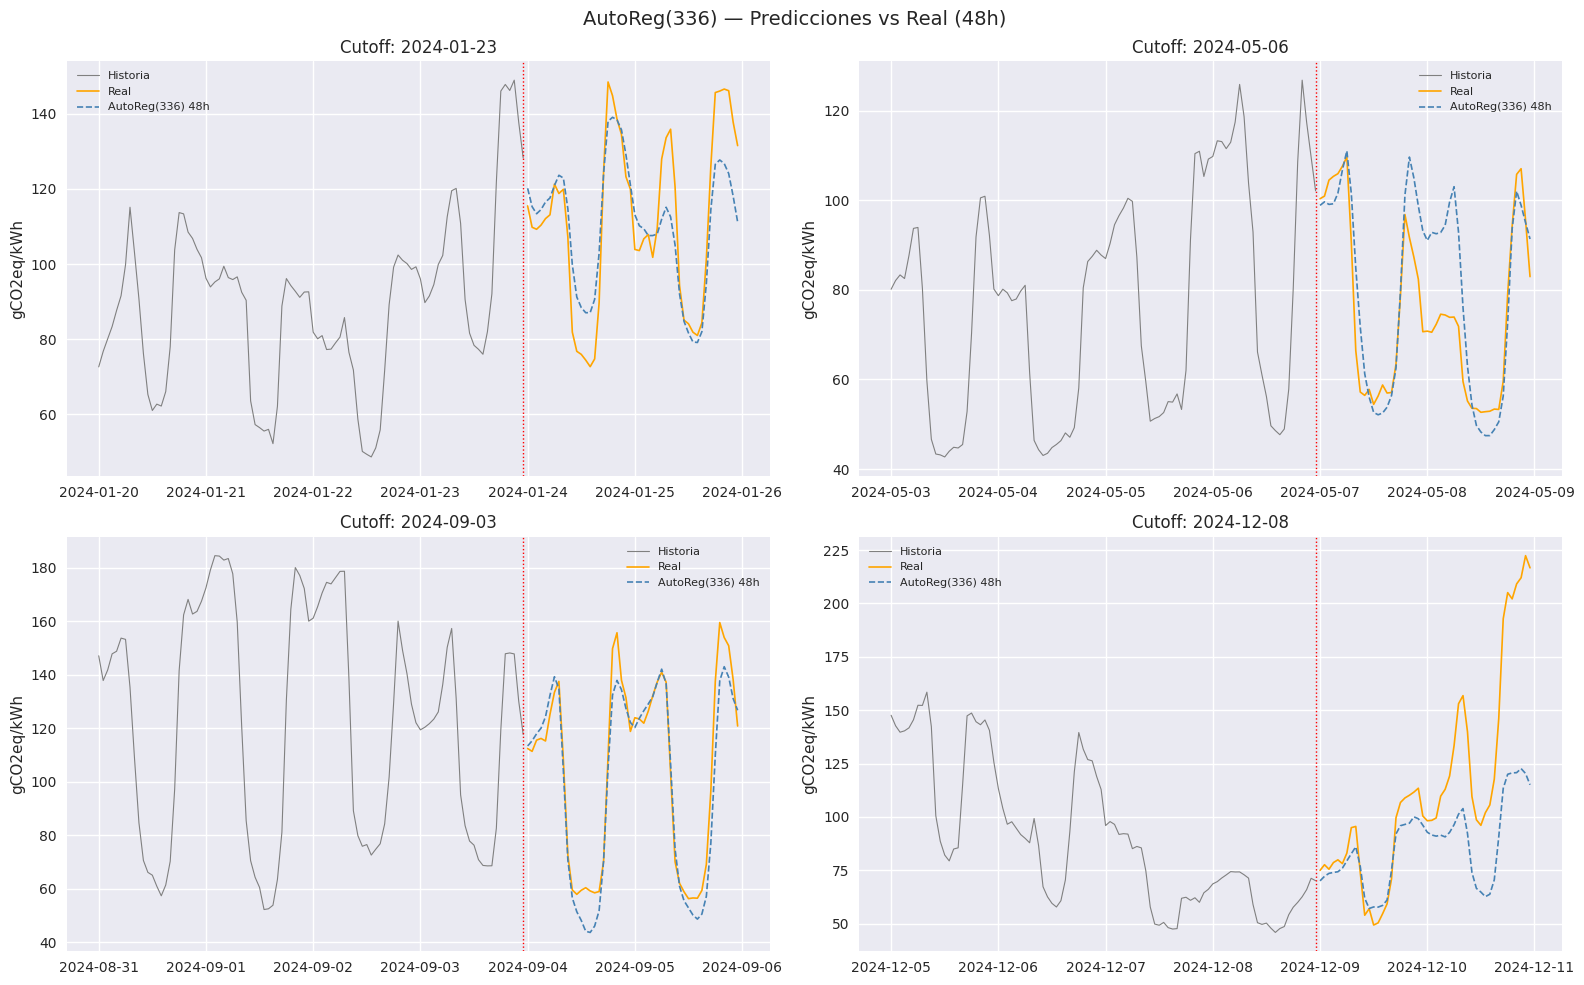

In [9]:
fig, axes = plt.subplots(2, 2, figsize=(16, 10))
fig.suptitle(f"AutoReg({LAGS_OPT}) — Predicciones vs Real (48h)", fontsize=14)

for idx, split_idx in enumerate(PLOT_INDICES):
    ax          = axes[idx // 2][idx % 2]
    fit         = preds_store[split_idx]
    cutoff_time = fit["cutoff_time"]
    train_w     = fit["train_window"]
    test        = fit["48h"]["test"]
    pred        = fit["48h"]["pred"]
    history     = train_w.iloc[-4 * SEASONAL_PERIOD:]

    ax.plot(history.index, history.values,
            color="gray", label="Historia", linewidth=0.8)
    ax.plot(test.index, test.values,
            color="orange", label="Real", linewidth=1.2)
    ax.plot(test.index, pred,
            color="steelblue", linestyle="--",
            label=f"AutoReg({LAGS_OPT}) 48h", linewidth=1.2)
    ax.axvline(x=cutoff_time, color="red", linestyle=":", linewidth=1)
    ax.set_title(f"Cutoff: {cutoff_time.date()}")
    ax.set_ylabel("gCO2eq/kWh")
    ax.legend(fontsize=8)

plt.tight_layout()
plt.savefig(FIG_DIR / "autoreg_predicciones.png", dpi=150, bbox_inches="tight")
plt.show()

## 10. Comparación con modelos anteriores

Se combinan los resultados de todos los modelos estadísticos evaluados
hasta este punto — Naive, ARIMA, SARIMA y AutoReg — para una comparación
directa. Los intervalos de confianza al 95% permiten determinar si las
diferencias entre modelos son estadísticamente significativas.

In [10]:
naive_arima_ci = pd.read_csv(RESULTS_DIR / "comparacion_naive_arima_ci.csv")

all_ci = pd.concat([naive_arima_ci, autoreg_ci], ignore_index=True)

print("\n========== COMPARACIÓN FINAL ==========\n")
for _, r in all_ci.iterrows():
    print(f"{r['model']:25s} {r['horizon']:4s}  "
          f"MAE = {r['MAE_mean']:6.2f} ± {r['MAE_std']:5.2f}  "
          f"IC95% [{r['MAE_ci_lo']:6.2f}, {r['MAE_ci_hi']:6.2f}]  "
          f"(n={int(r['n_eval'])})")

all_ci.to_csv(RESULTS_DIR / "comparacion_estadisticos_ci.csv", index=False)


========== COMPARACIÓN FINAL ==========

Naive_last                48h   MAE =  29.62 ± 14.18  IC95% [ 25.60,  33.84]  (n=45)
Naive_last                72h   MAE =  32.52 ± 16.13  IC95% [ 28.00,  37.54]  (n=45)
Naive_seasonal            48h   MAE =  20.84 ± 14.78  IC95% [ 16.83,  25.59]  (n=45)
Naive_seasonal            72h   MAE =  23.01 ± 16.91  IC95% [ 18.37,  28.50]  (n=45)
ARIMA(2, 1, 2)            48h   MAE =  26.95 ± 12.42  IC95% [ 23.49,  30.95]  (n=45)
ARIMA(2, 1, 2)            72h   MAE =  28.89 ± 14.41  IC95% [ 24.93,  33.23]  (n=45)
AutoReg(336)              48h   MAE =  17.39 ± 14.24  IC95% [ 13.58,  22.32]  (n=45)
AutoReg(336)              72h   MAE =  18.98 ± 15.25  IC95% [ 14.77,  24.02]  (n=45)


## 11. Interpretación de resultados

*Pendiente de actualizar con los resultados de la evaluación a resolución horaria.*

AutoReg utiliza únicamente rezagos de la propia serie como predictores.
Se analizará si el número óptimo de lags captura la estacionalidad diaria
implícitamente y si AutoReg supera a SARIMA sin necesidad de una
componente estacional explícita.